# Tutorial for emulating bias-per-object as a fn. of cosmology and Mstar

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt

import torch
import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner 
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.chdir('/mnt/home/fmaion/packages/bias_tools/src/')
import cutter as cutter

In [3]:
os.chdir('/mnt/ceph/users/fmaion/projects/bias_priors/src')
import utils

In [4]:
def mean_bias_relation(b_gal, mstar, q=None):
    
    m_edges = np.array([[8.5,9],[9,9.5],[9.5,10],[10,10.5],[10.5,11],[11,11.5],[11.5,12],[12,12.5]])
    m_centers = 0.5 * ( m_edges[:,0] + m_edges[:,1] )
    
    b_gal_mstar = np.zeros((m_edges.shape[0], 3))
    bcov_gal_mstar = np.zeros((m_edges.shape[0],3,3))
    
    mstar_weight = np.zeros(m_edges.shape[0])
    mstar_sel = {}
    
    for i in range(m_edges.shape[0]):
        mstar_sel[i] = np.where( ( mstar > m_edges[i][0] ) & ( mstar < m_edges[i][1] ) )[0]
        mstar_weight[i] = np.mean(mstar[mstar_sel[i]])

        if q is not None:
            b_gal_mstar[i], bcov_gal_mstar[i] = cutter.fit_from_bpo(bpo=b_gal, box=50, IA=False, tr_q=q, mask=mstar_sel[i])
        else:
            b_gal_mstar[i] = np.mean(b_gal[mstar_sel[i],:], axis=0)
            bcov_gal_mstar[i] = np.std(b_gal[mstar_sel[i],:],axis=0) / np.sqrt(len(mstar_sel[i]))

    return mstar_weight, b_gal_mstar, bcov_gal_mstar

In [5]:
pars = utils.load_CAMELS_50_1P_parameters()
biases, mstar = utils.load_CAMELS_50_1P_biases()

## Function for getting parameters ready for NN evaluation

In [9]:
def get_1P_pars_for_NPE(mstar, pars, par_i, sim_j):
    
    pars_sel = np.array([1, 2, 3, 5, 7, 8, 9, 12, 13, 16, 18, 19, 23, 26])

    _pars = np.copy(pars[pars_sel[par_i-1]][sim_j][pars_sel-1])
    
    theta = np.repeat(_pars[:,np.newaxis], len(mstar), axis=1)
    theta = np.concatenate((theta, mstar[np.newaxis, :]), axis=0).T
    
    return theta

In [10]:
def combine_pars_sm_optimized(cosmo_astro, mstar):
    # 1. Get the length of each sub-array in mstar
    # This tells NumPy how many times to repeat each row of cosmo_astro
    repeats = np.array([len(mstar[i]) for i in range(len(mstar))])
    
    # 2. Repeat the cosmo_astro rows to match the mstar lengths
    # np.repeat(array, repeats, axis=0) does the heavy lifting
    pars_expanded = np.repeat(cosmo_astro, repeats, axis=0)
    
    # 3. Flatten the mstar list into a single 1D array
    mstar_1d = np.concatenate([mstar[i] for i in range(len(mstar))])
    
    # 4. Combine them (horizontal stack / column stack)
    return np.column_stack([pars_expanded, mstar_1d])

## Load the trained model

In [11]:
import pickle
import json

basepath = '/mnt/ceph/users/fmaion/projects/bias_priors/training_results/bias_NPE_large_log_14_bs_v2/'

with open(basepath+'bias_NPE_large_log_14_bs_v2_posterior.pkl', 'rb') as f:
    # This loads the object exactly as it was saved
    posterior = pickle.load(f)

with open(basepath+'bias_NPE_large_log_14_bs_v2_summary.json', 'rb') as f:
    summaries = json.load(f)

/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/home/fmaion/packages/ltu-ili/.ltu_venv/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/mnt/home/fmaion/

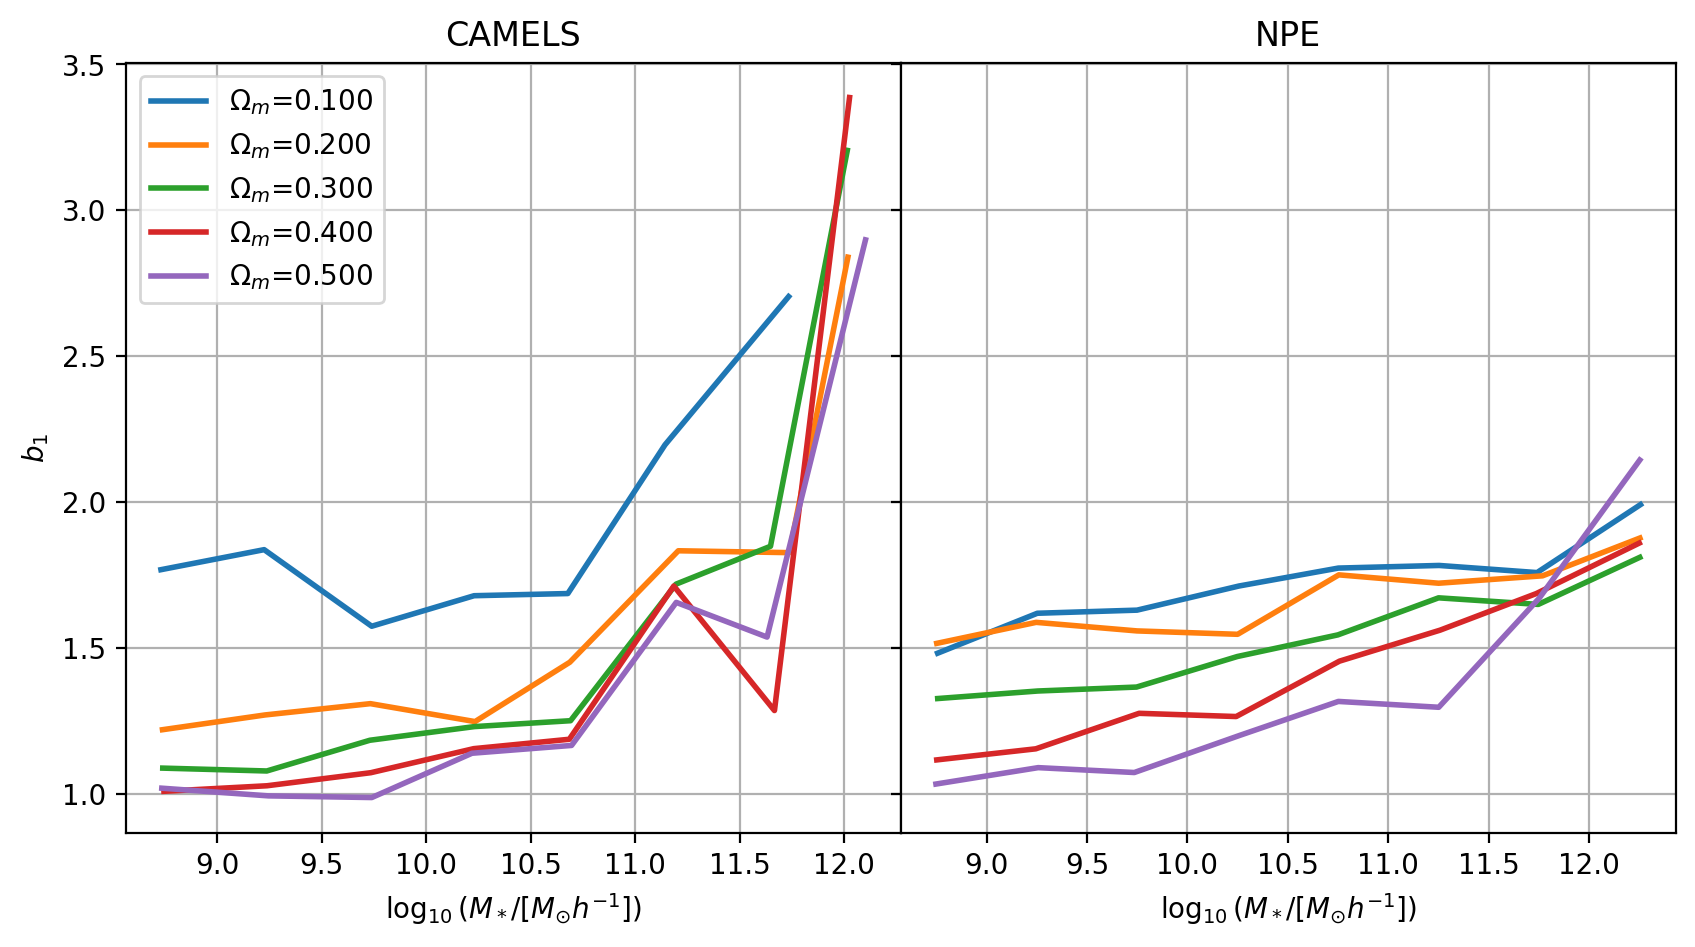

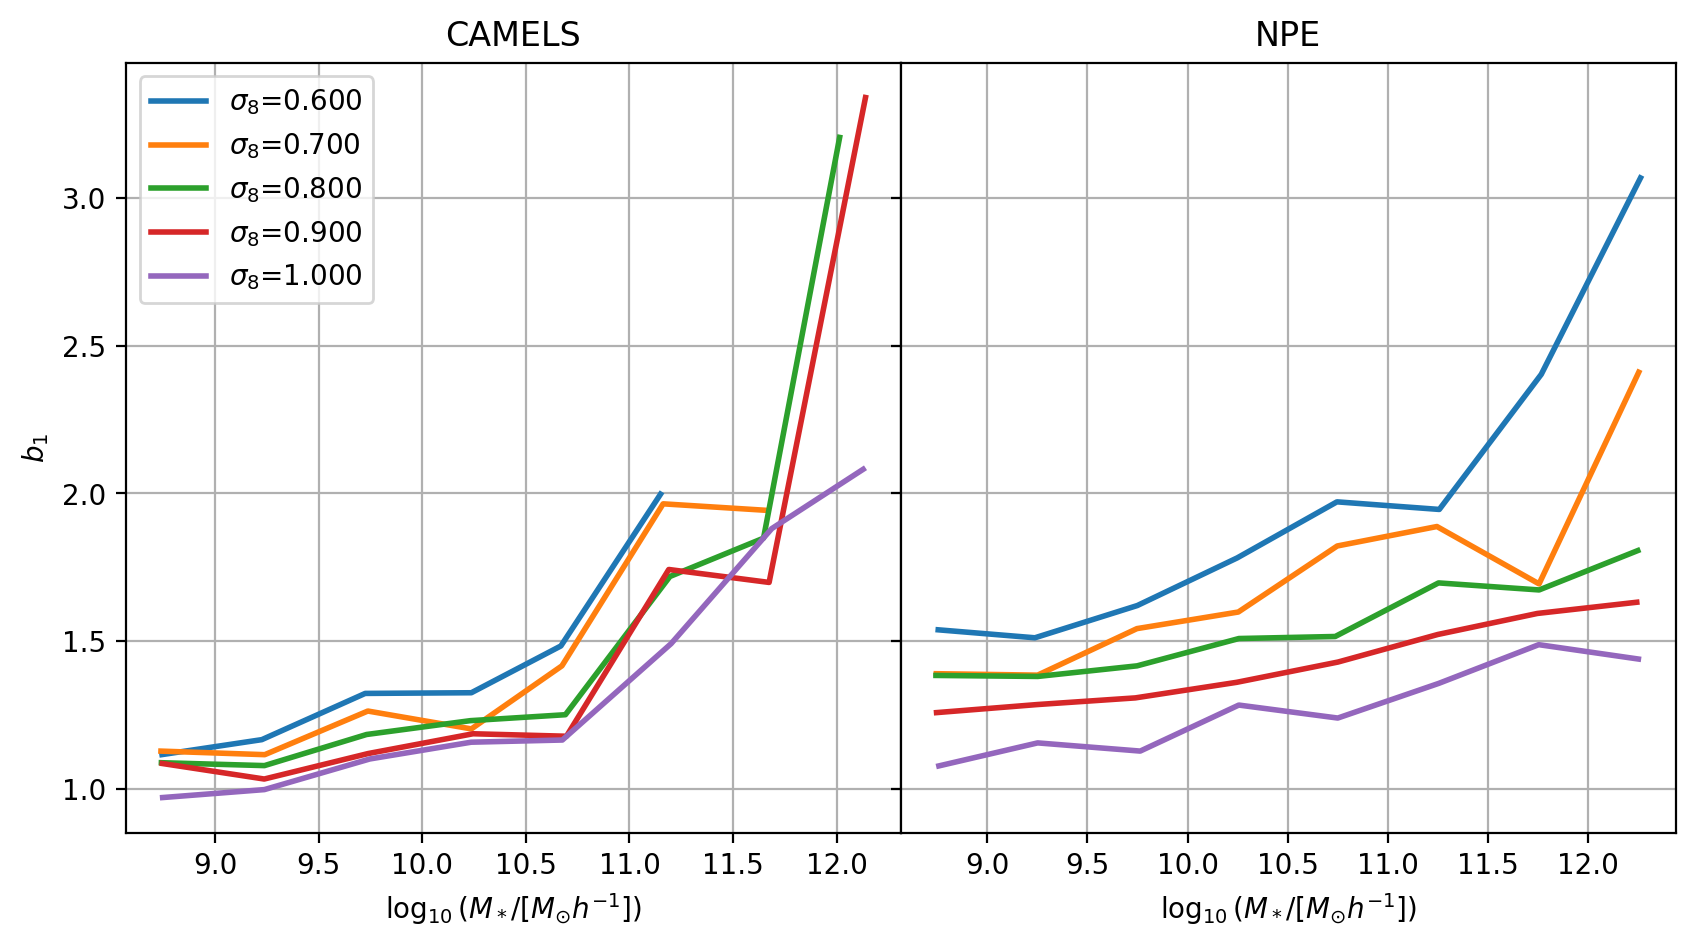

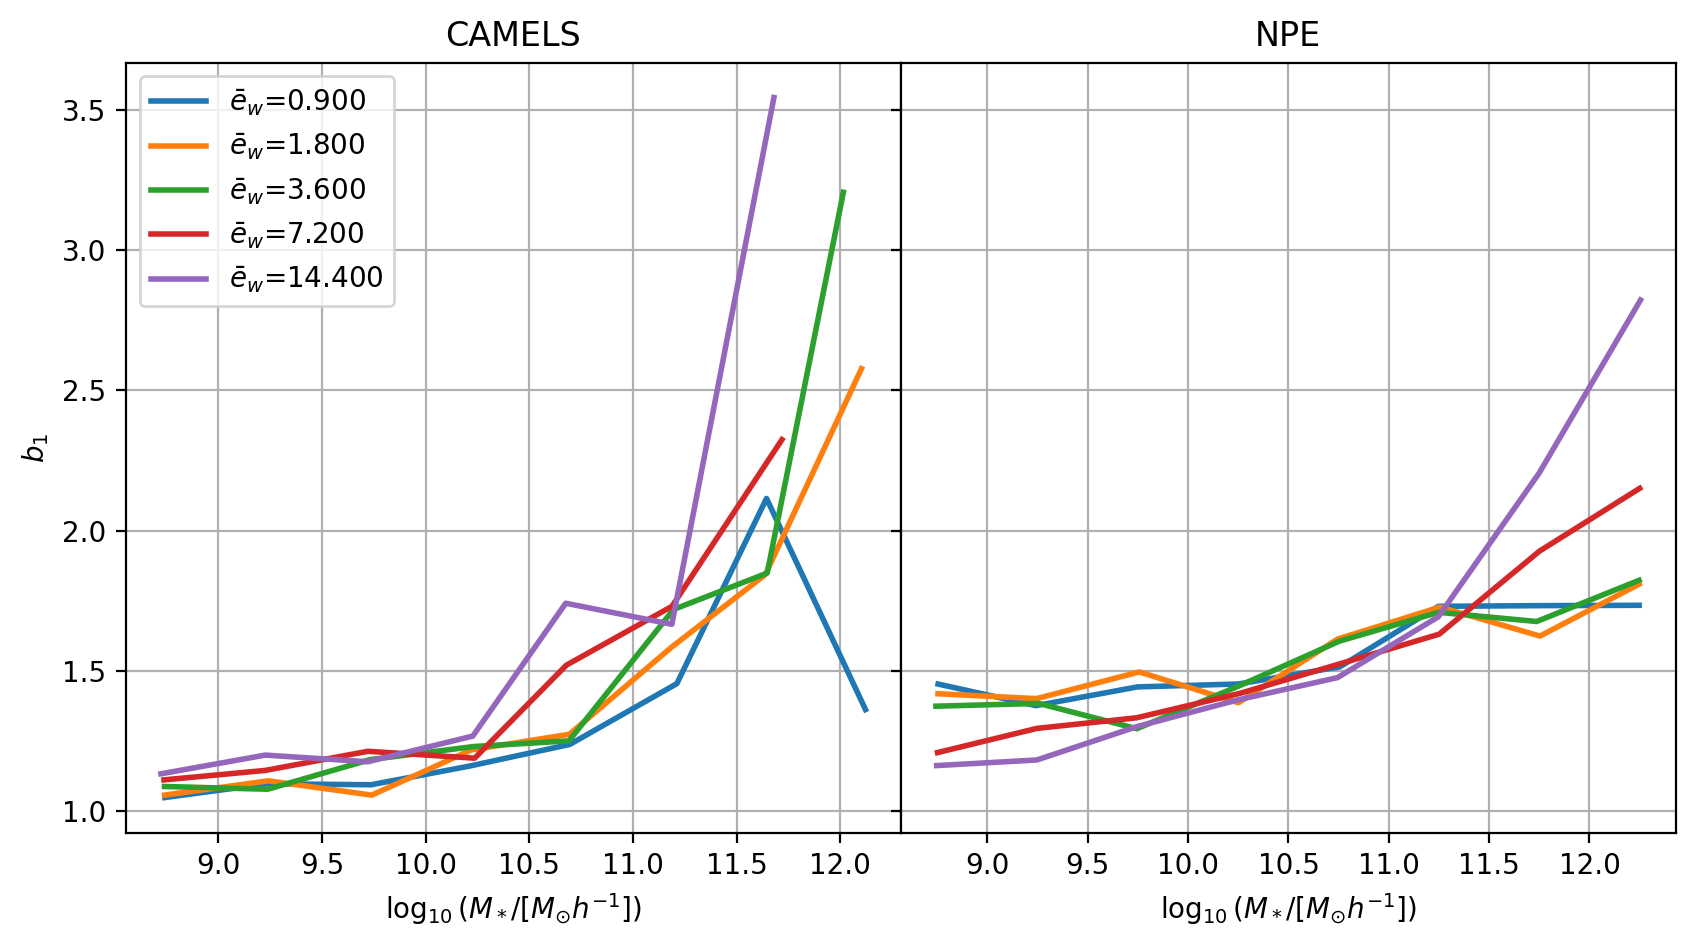

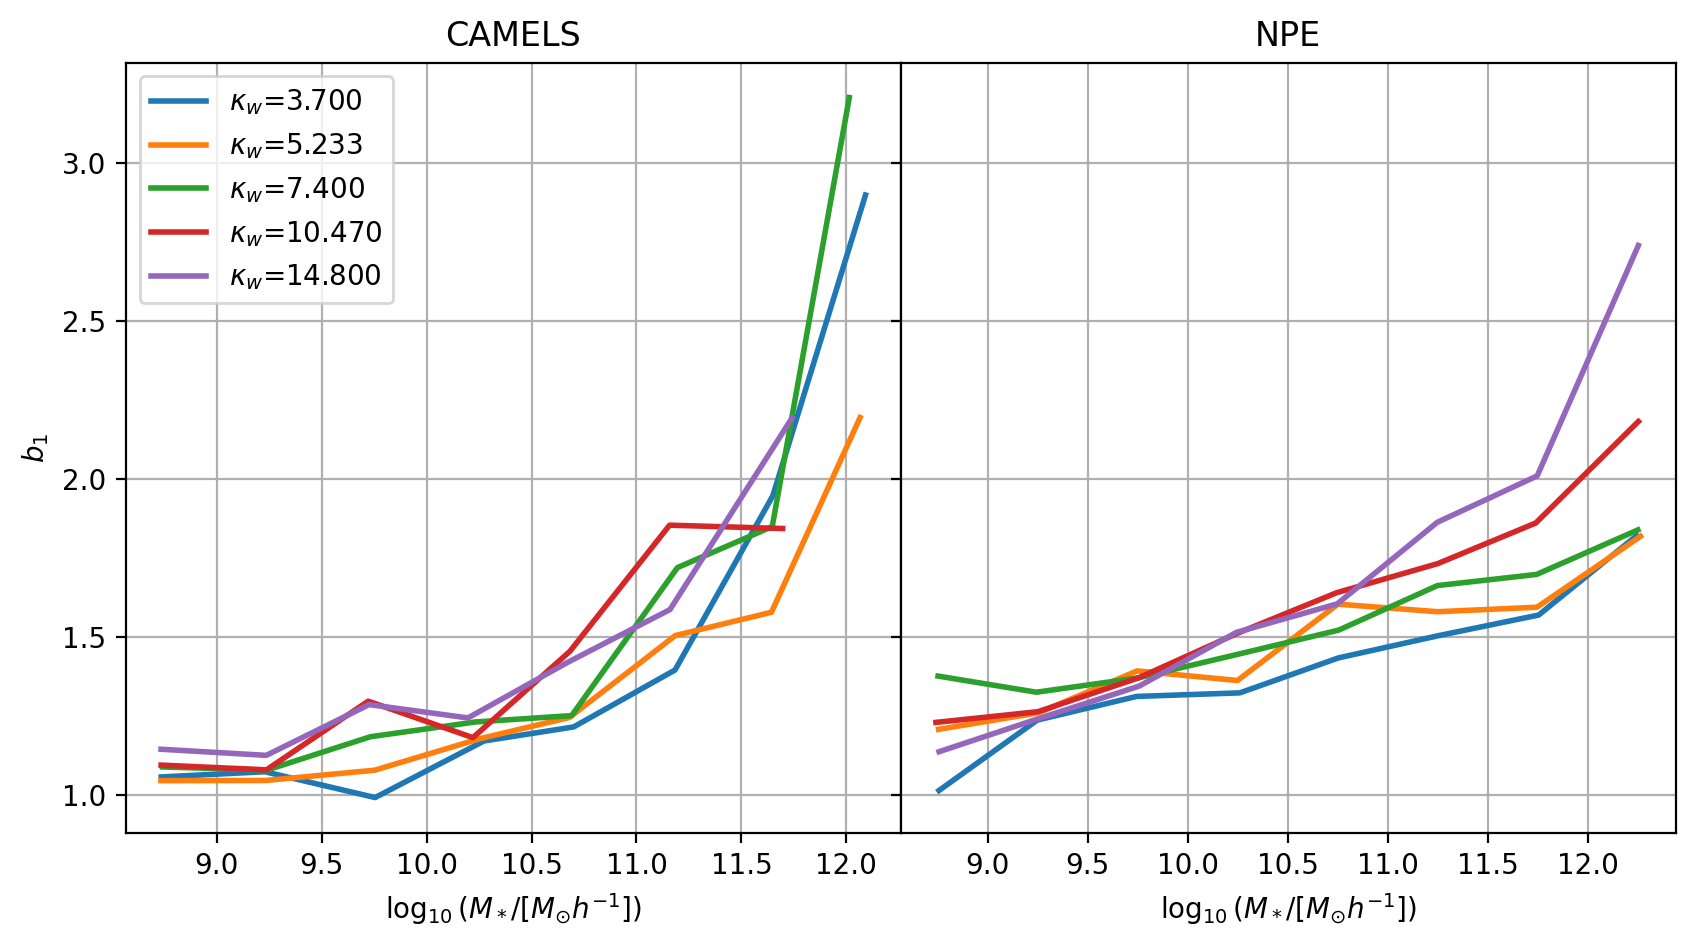

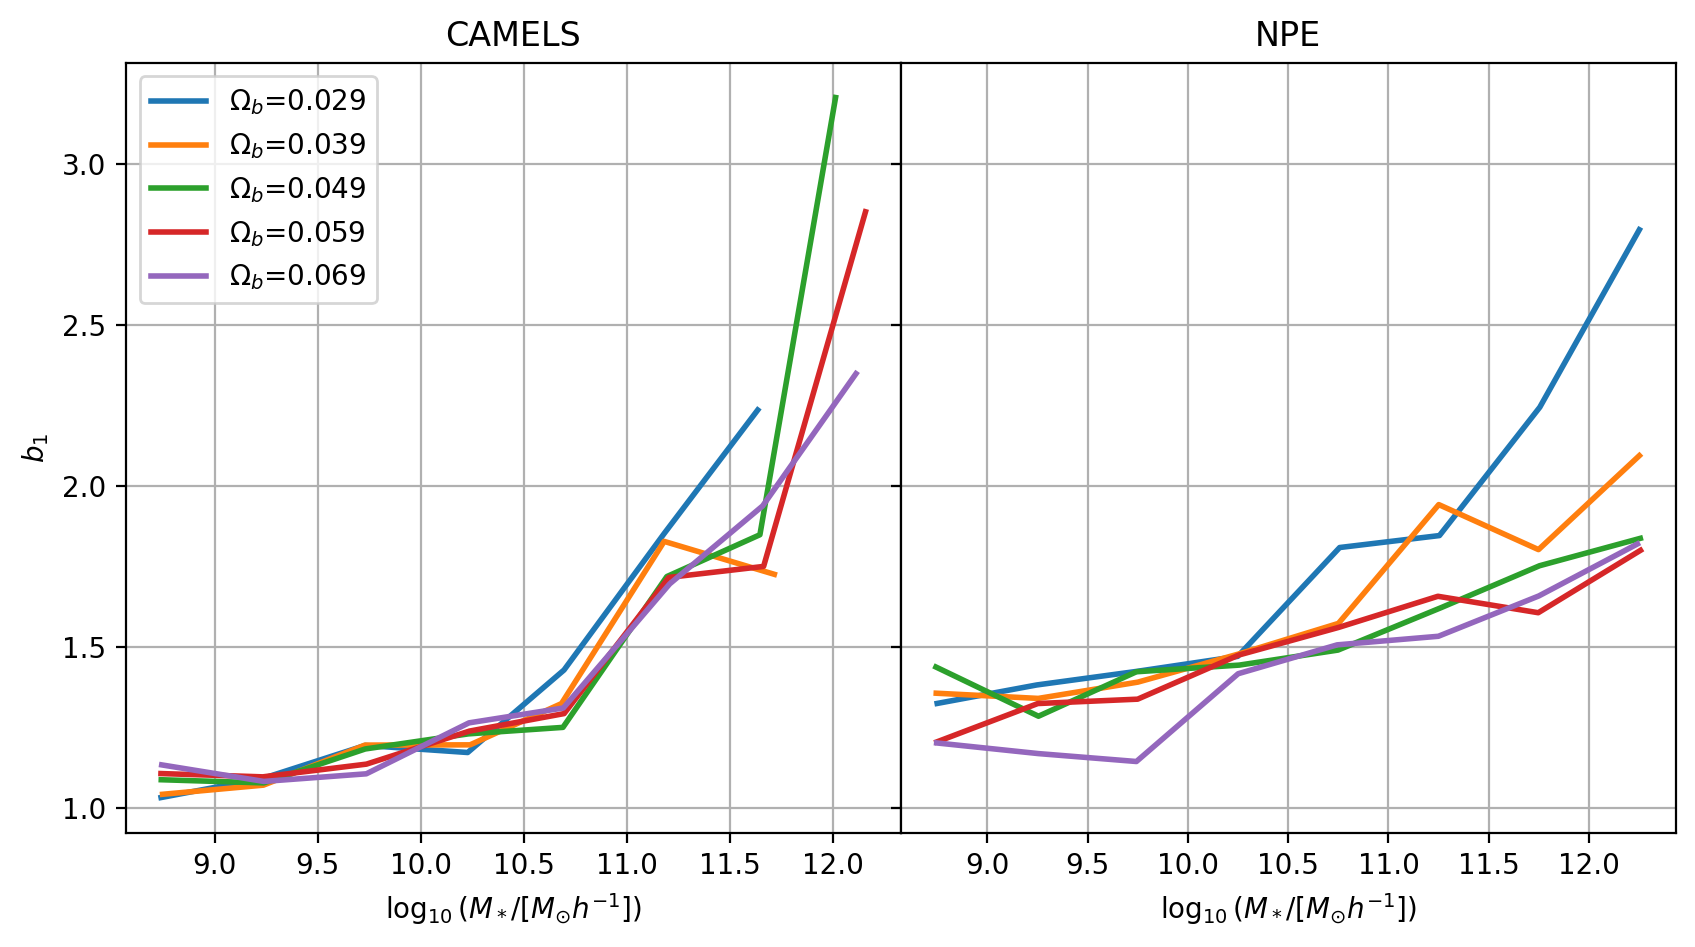

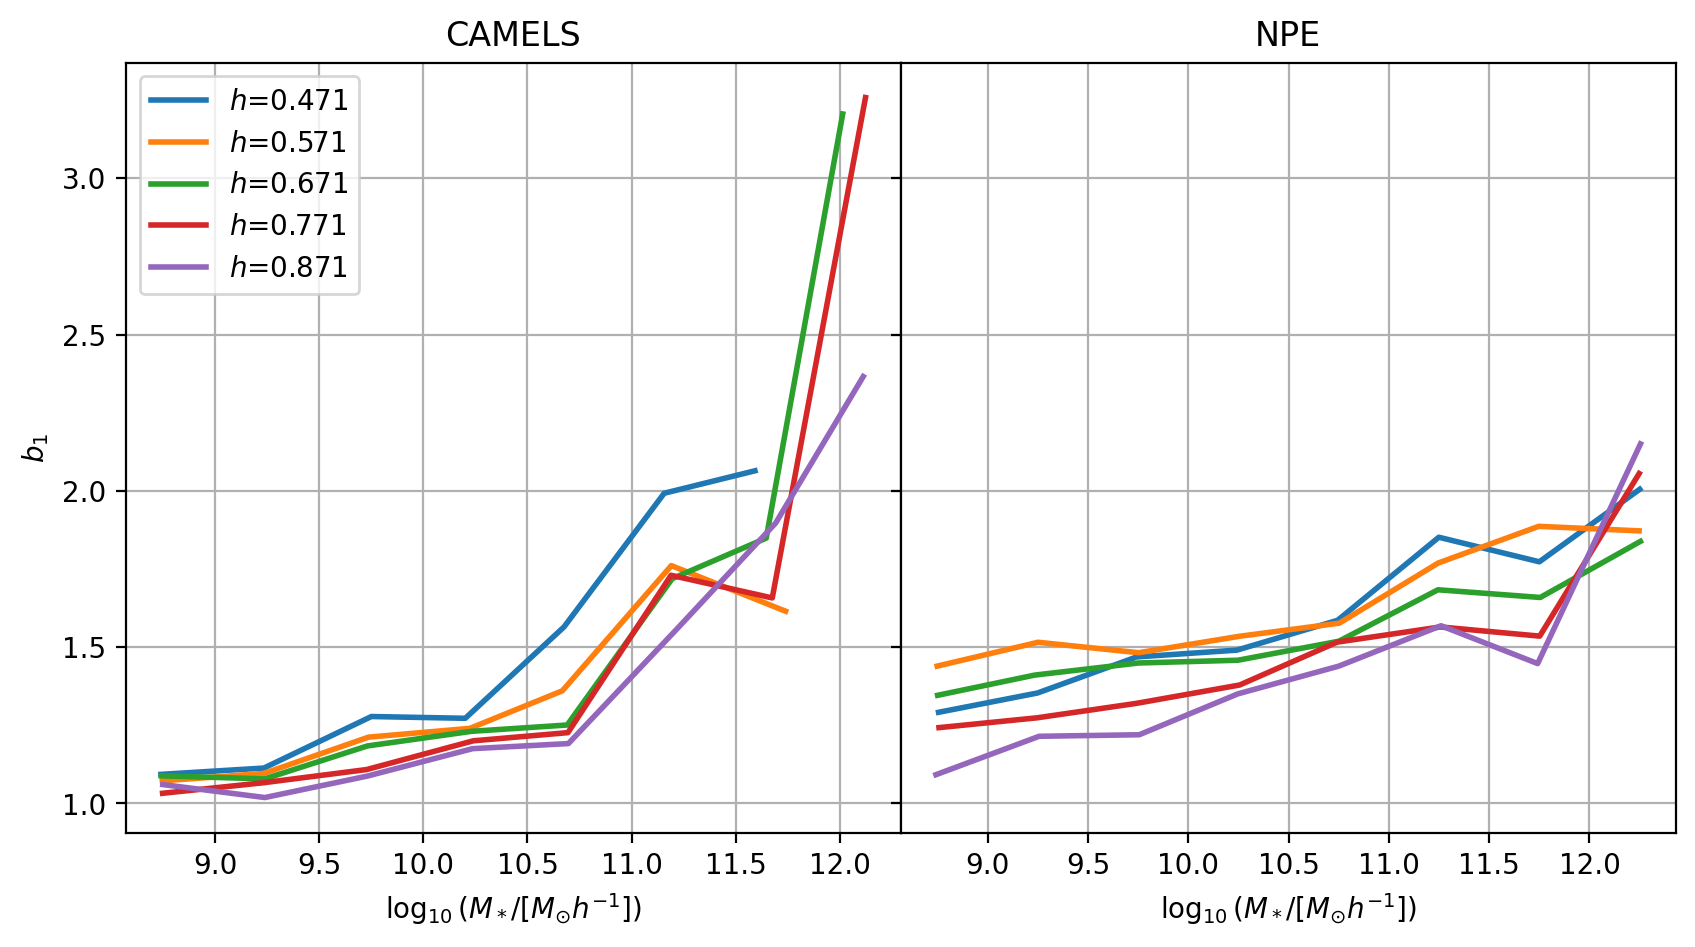

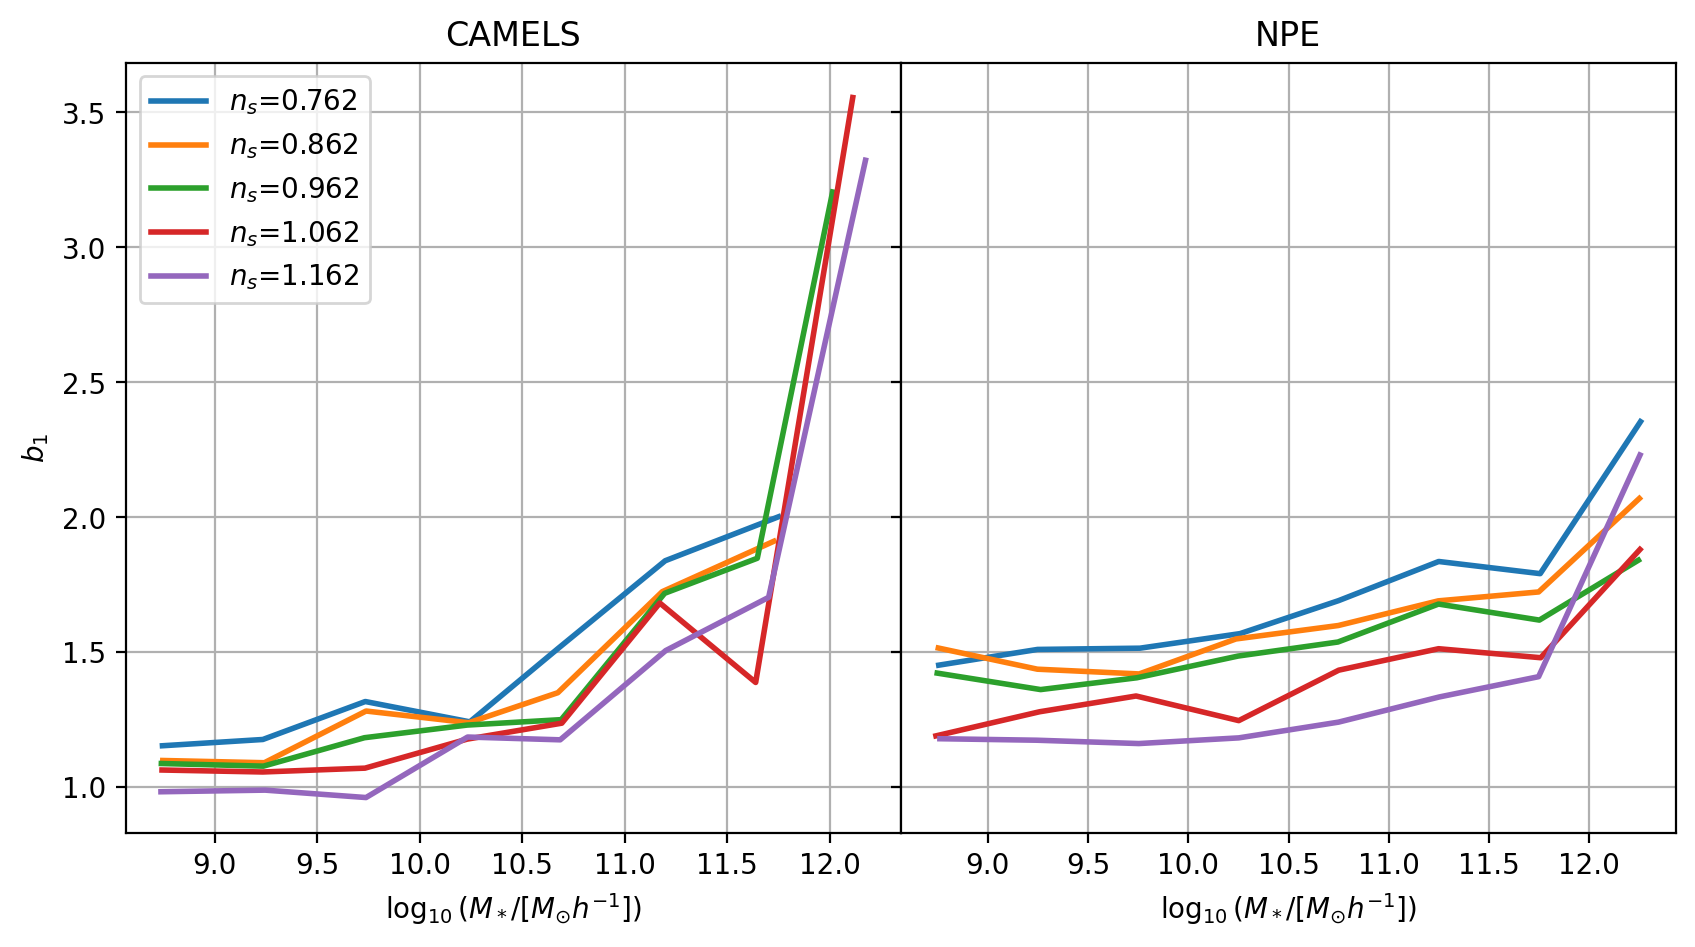

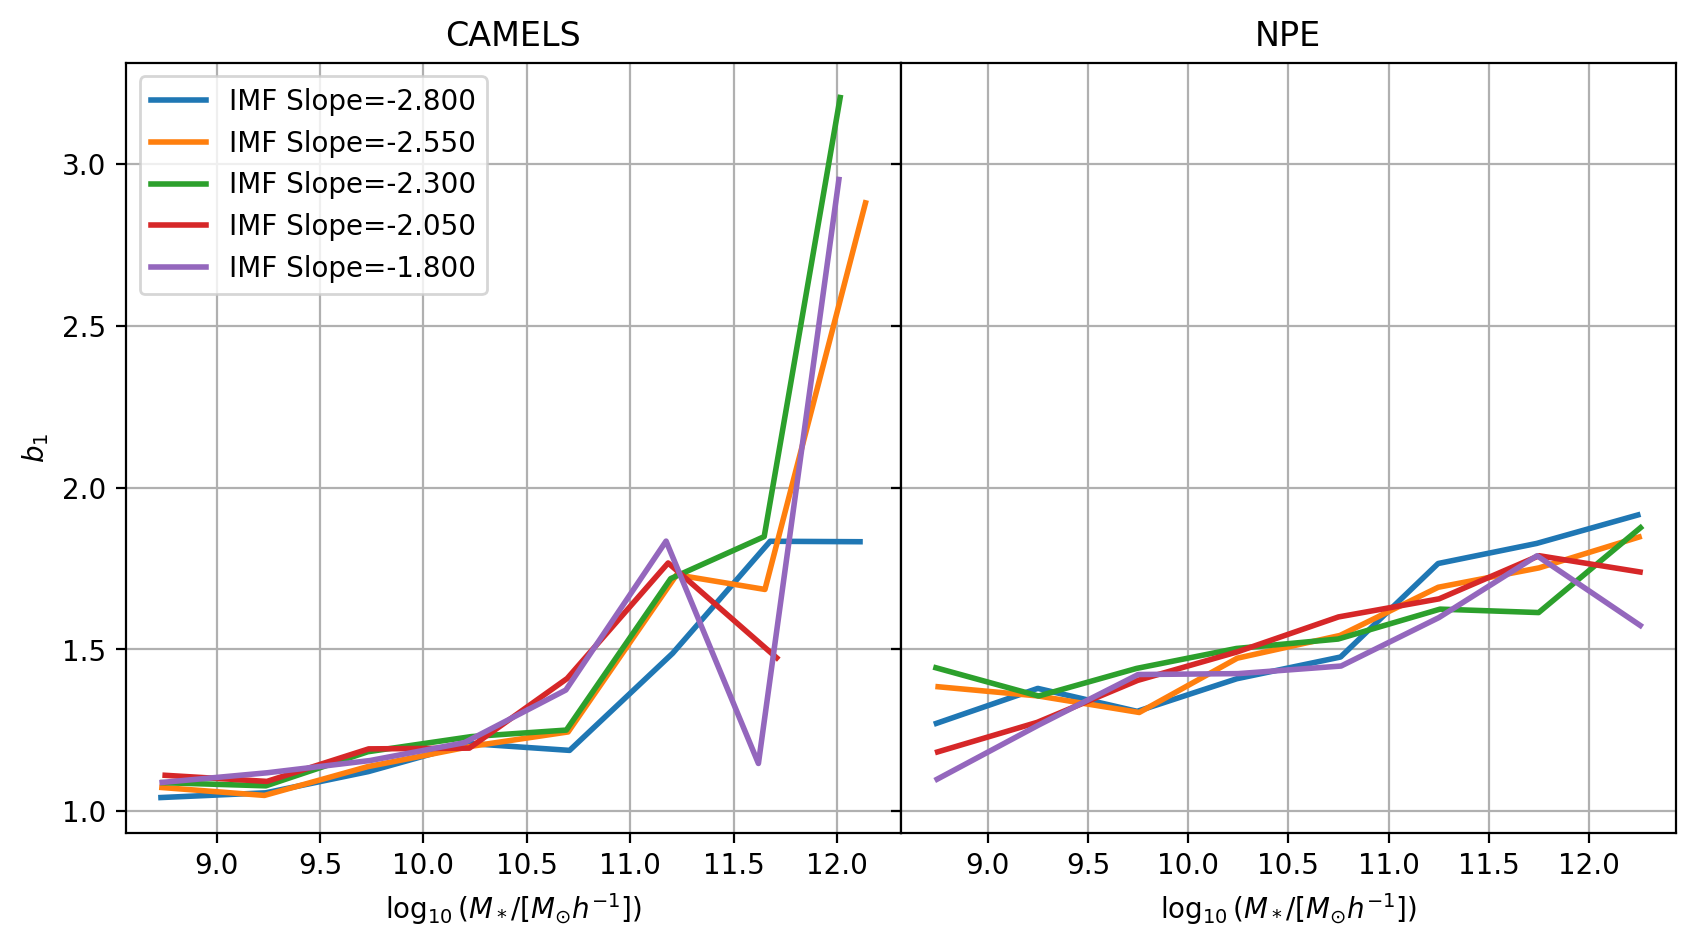

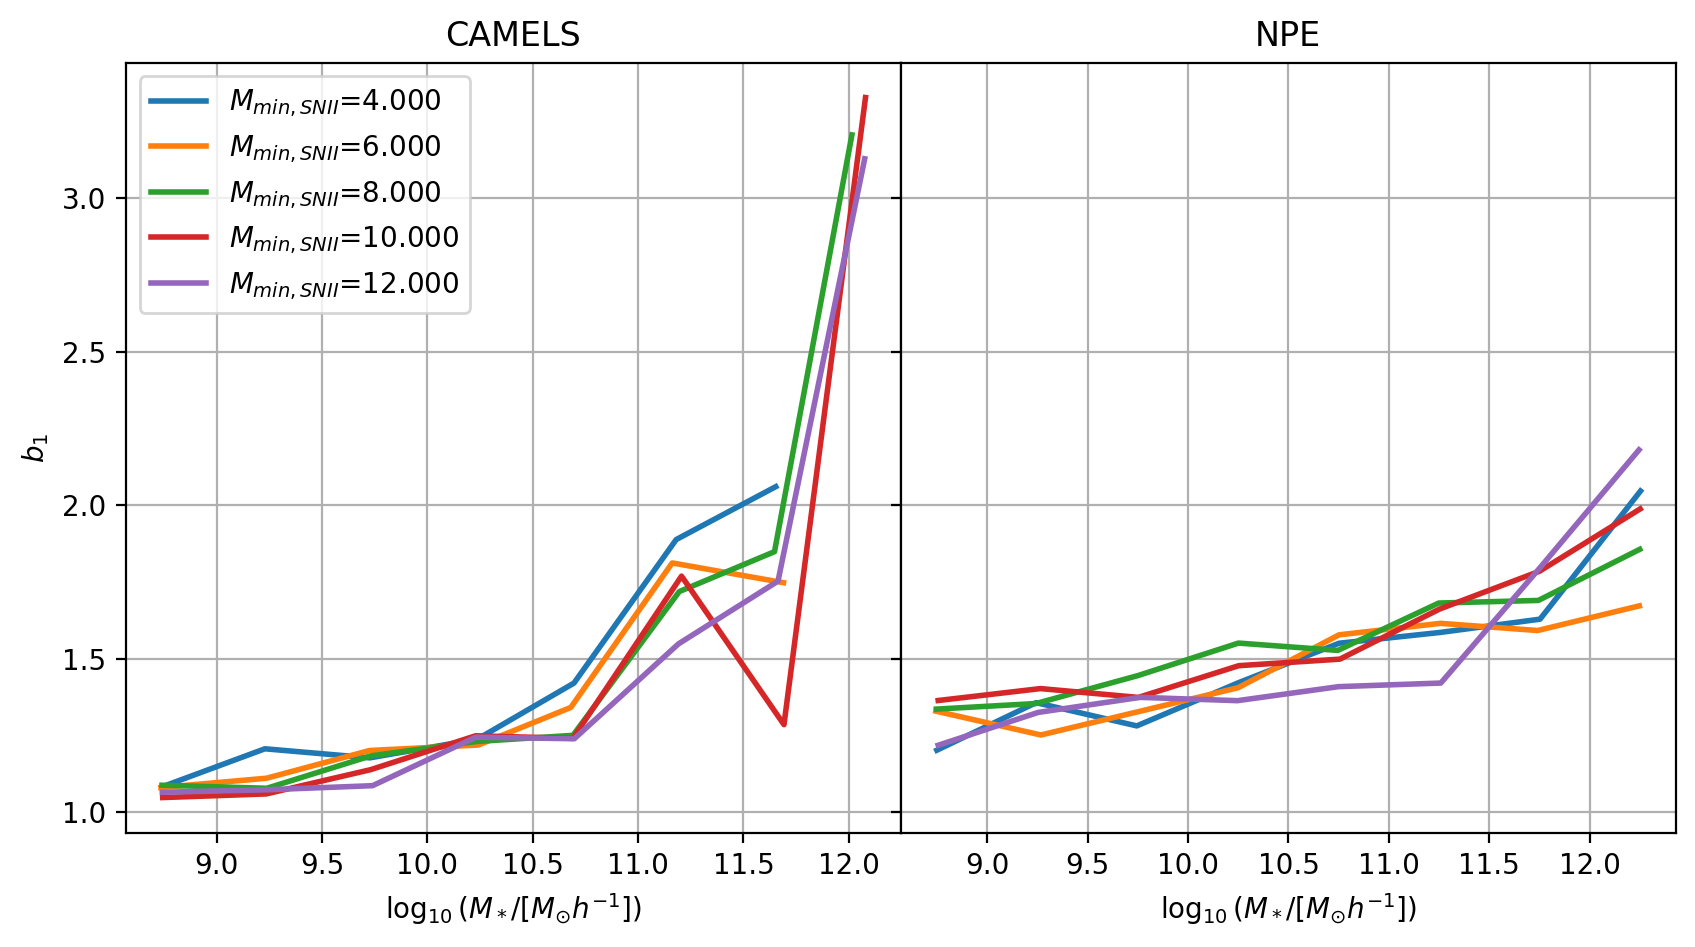

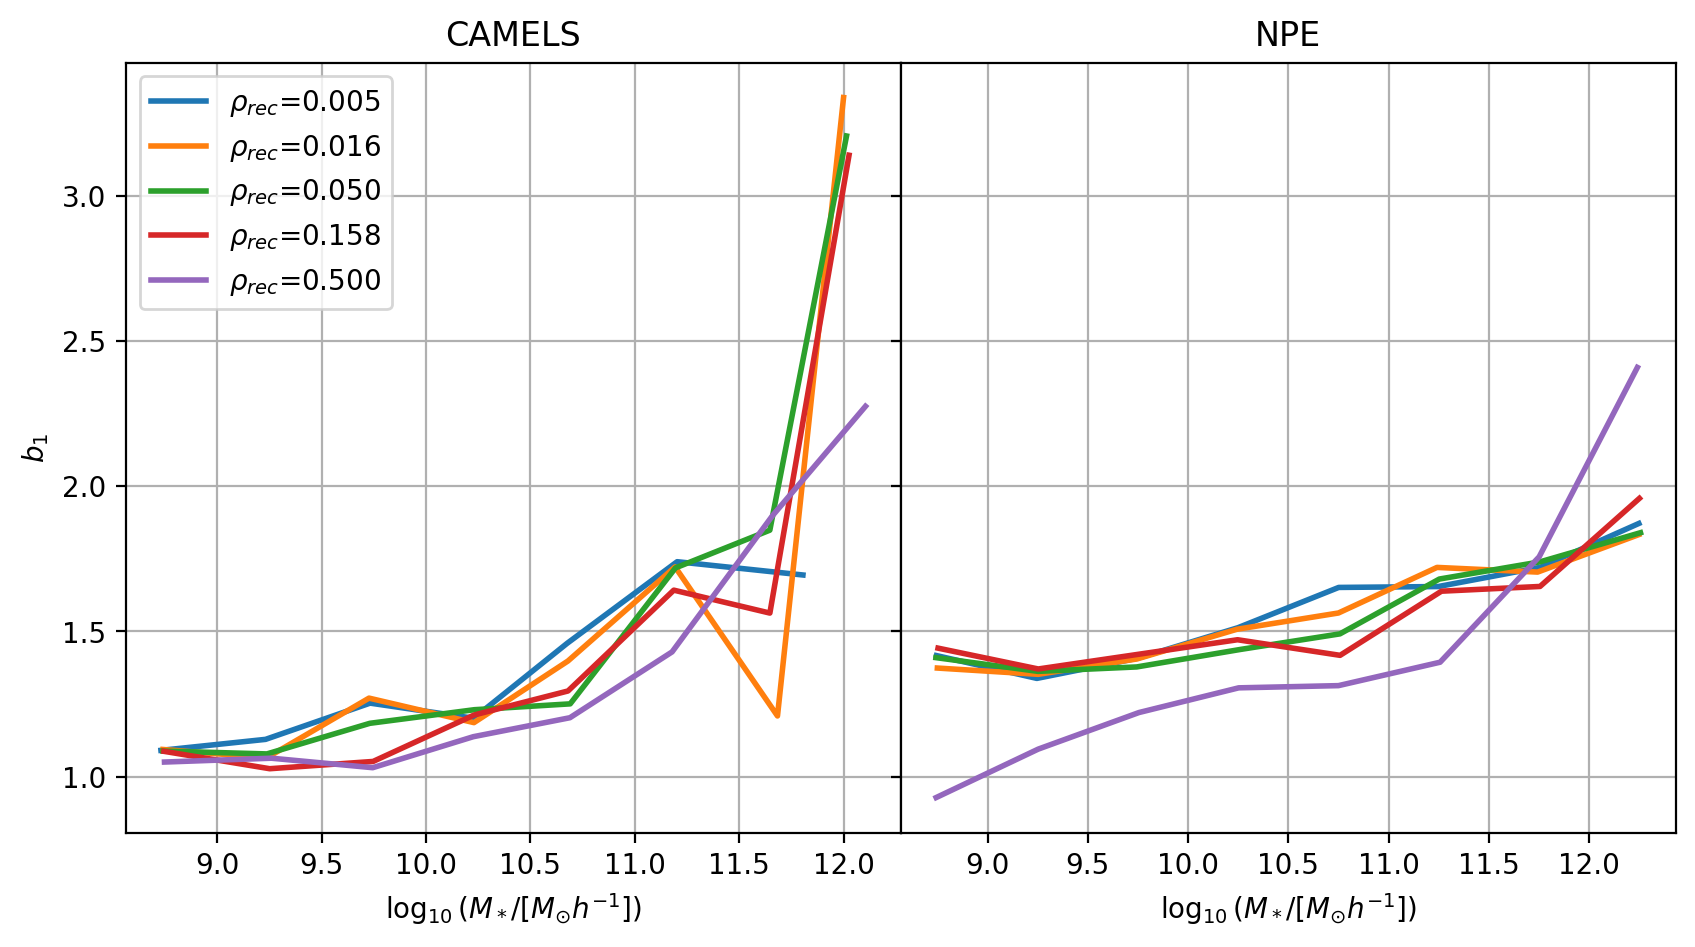

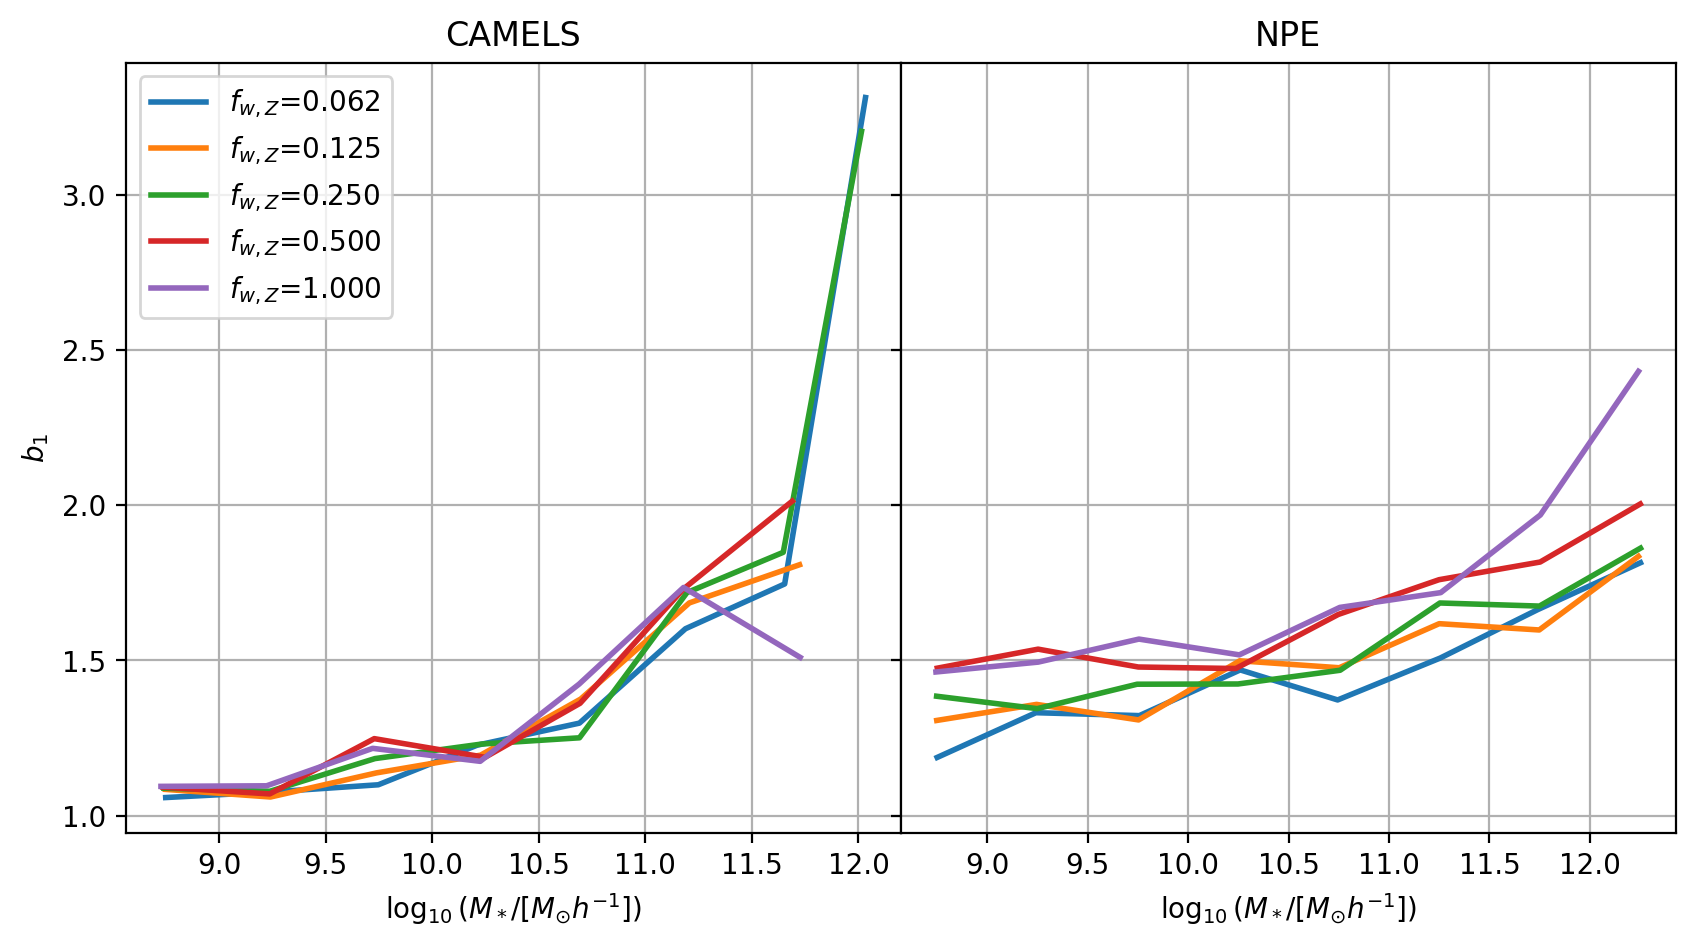

In [12]:
pars_sel = np.array([1, 2, 3, 5, 7, 8, 9, 12, 13, 16, 18, 19, 23, 26])

par_names = np.array(['$\Omega_m$', '$\sigma_8$', '$\\bar{e}_w$', '$\\epsilon_{f,kin}$', '$\kappa_w$', '$f_{re}$', '$\Omega_b$', '$h$', '$n_s$', '$t_*$', 'EQS Factor', 'IMF Slope',
             '$M_{min, SNII}$', '$\tau_w$', 'Wind Spec. Momentum', '$\\rho_{rec}$', '$v_{w,min}$', '$f_{w,Z}$', '$Z_{w,ref}$', '$\\gamma_{w,Z}$', 'Wind dump Factor',
             '$M_{BH,seed}$', 'BH Acc. Factor', 'Edd. Factor', 'Feedback Factor', '$\\epsilon_r$', '$\\chi$', '$\\beta$', 'UVBH0beta',\
                                  'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz', 'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power',\
                                  'SofteningComovingType01'])
par_names = par_names[pars_sel - 1]

for i in range(1,12):
    fig, ax = plt.subplots(1, 2, dpi=200, figsize=(10, 5), sharey=True)

    for sim_j in range(5):
        par_i = i
        
        mstar_1P = mstar[pars_sel[par_i-1]][sim_j]
        bgal_1P = biases[pars_sel[par_i-1]][sim_j]

        mstar_sample = np.random.uniform(low=8, high=15, size=(10000,))
        
        theta = get_1P_pars_for_NPE(mstar_sample, pars, par_i, sim_j)
        
        samples = posterior.sample(len(mstar_sample), theta, show_progress_bars=False).cpu().numpy()
        
        ms_test_w, b_test, bcov_test = mean_bias_relation(bgal_1P, mstar_1P, q=None)
        ms_sample, b_sample, bcov_sample = mean_bias_relation(samples, mstar_sample, q=None)
    
        theta_plot = np.copy(theta)
        ax[0].plot(ms_test_w, 1 + b_test[:,0], color='C'+str(sim_j), lw=2, alpha=1, label=par_names[par_i-1]+'={:.3f}'.format(theta_plot[0,par_i-1]))
        ax[1].plot(ms_sample, 1 + b_sample[:,0], color='C'+str(sim_j), lw=2, alpha=1)
    
    ax[0].legend(loc='upper left')
    ax[0].grid()
    ax[1].grid()
    
    plt.subplots_adjust(hspace=0,wspace=0)
    
    ax[0].set_ylabel("$b_1$")
    ax[0].set_xlabel("$\log_{10}(M_*/[M_{\odot}h^{-1}])$")
    ax[1].set_xlabel("$\log_{10}(M_*/[M_{\odot}h^{-1}])$")
    ax[0].set_title("CAMELS")
    ax[1].set_title("NPE")

NameError: name 'mean_std_filename' is not defined

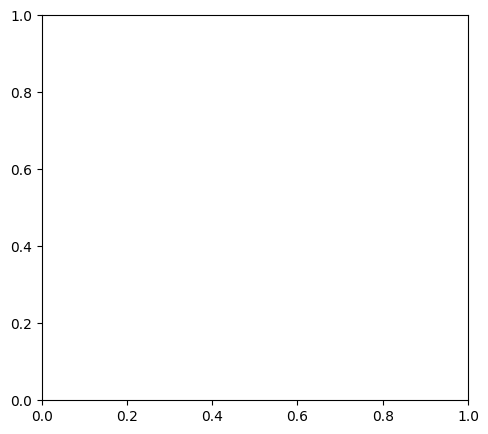

In [13]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

# ax.set_ylim(-5, 5)

for sim_j in range(5):
    par_i = 3
    
    mstar_1P = mstar[par_i][sim_j]
    bgal_1P = biases[par_i][sim_j]
    
    theta = get_1P_pars_for_NPE(mstar, pars, par_i, sim_j, mean_std_filename)
    
    # samples = [posterior.sample(1, theta[i,:], show_progress_bars=False).cpu().numpy() for i in range(theta.shape[0])]
    samples = posterior.sample(10000*len(mstar_1P), theta, show_progress_bars=False).cpu().numpy()
    # samples = np.array(samples)
    # samples = rescale_b1(samples, mean_std_filename)
    
    ms_test_w, b_test, bcov_test = mean_bias_relation(bgal_1P, mstar_1P, q=None)
    ms_sample, b_sample, bcov_sample = mean_bias_relation(samples, mstar_1P, q=None)

    theta_plot = np.copy(theta)
    theta_plot = rescale_theta(theta_plot, mean_std_filename)
    ax.plot(ms_sample, 1+b_test[:,0], color='C'+str(sim_j), lw=1, alpha=1, ls='--')
    ax.plot(ms_sample, 1+b_sample[:,0], color='C'+str(sim_j), lw=1, alpha=1, label='$W_e={:.3f}$'.format(theta_plot[0,2]))

ax.legend()

NameError: name 'mean_std_filename' is not defined

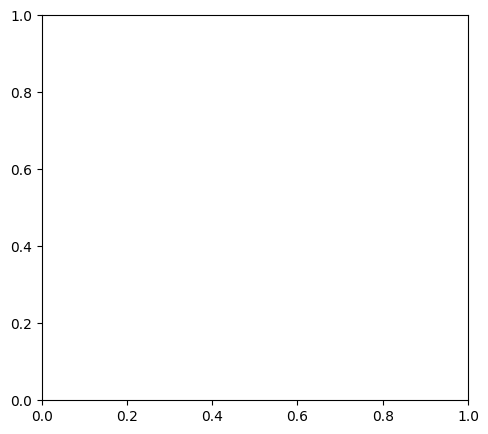

In [14]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

# ax.set_ylim(-5, 5)

for sim_j in range(5):
    par_i = 4
    
    mstar_1P = mstar[par_i][sim_j]
    bgal_1P = biases[par_i][sim_j]
    
    theta = get_1P_pars_for_NPE(mstar, pars, par_i, sim_j, mean_std_filename)
    
    # samples = [posterior.sample(1, theta[i,:], show_progress_bars=False).cpu().numpy() for i in range(theta.shape[0])]
    samples = posterior.sample(10000*len(mstar_1P), theta, show_progress_bars=False).cpu().numpy()
    # samples = np.array(samples)
    # samples = rescale_b1(samples, mean_std_filename)
    
    ms_test_w, b_test, bcov_test = mean_bias_relation(bgal_1P, mstar_1P, q=None)
    ms_sample, b_sample, bcov_sample = mean_bias_relation(samples, mstar_1P, q=None)

    theta_plot = np.copy(theta)
    theta_plot = rescale_theta(theta_plot, mean_std_filename)
    # ax.plot(ms_sample, 1+b_test[:,0], color='C'+str(sim_j), lw=1, alpha=1, ls='--')
    ax.plot(ms_sample, 1+b_sample[:,0], color='C'+str(sim_j), lw=1, alpha=1, label='$Radio Feedback={:.3f}$'.format(theta_plot[0,3]))

ax.legend()

## Testing NPE for one single value of parameters

In [ ]:
# generate samples for a single, given test point
idx = 123
t_ = theta_test[idx]
x_ = x_test[idx]

print(f'Omega_m:, {t_[0]:.3f}')
print(f'sigma8: {t_[1]:.3f}')
print(f'logmstar: {t_[2]:.3f}')

samples = posterior_ensemble.sample((100,), t_).cpu().numpy()

f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(np.repeat(t_[4], len(samples)), samples, label='Emulator samples',
           marker='.', alpha=0.8)
ax.plot(t_[4], x_, 'rx',
        markersize=12, label='True value')
ax.legend()
ax.set(xlabel='b1', ylabel='b2')

### Now testing for a whole set of $M_*$ that share the same hydro-cosmo parameters

In [ ]:
for idx in range(len(test_ids)):
    print("Now doing {:d}".format(idx))
    id_sim = test_ids[idx]
    theta_sim = theta_test[ids[np.isin(ids, test_ids)] == id_sim] # Parameters of the simulation selected for comparison
    x_sim = x_test[ids[np.isin(ids, test_ids)] == id_sim] # Biases of the sim selected for comparison
    
    Nsamp = 1
    samples = [
        posterior_ensemble.sample((Nsamp,), t_, show_progress_bars=False).cpu().numpy() for t_ in theta_sim]
    samples = np.array(samples)
    logmstar_ = theta_sim[:, -1].repeat(Nsamp)
    
    f, ax = plt.subplots(figsize=(6, 5))
    
    binned_percentile_errorbar(
        logmstar_, samples[:, :, 0].flatten(), nbins=10, percentiles=(16, 50, 84),
        ax=ax, fmt='o-', color='C0',
        label='Emulator samples',
    )
    
    ax.plot(logmstar_, samples[:, : , 0], color="C0", label="Emulator Samples", marker="o", ms=1, ls='')
    ax.plot(theta_sim[:, -1], x_sim[:, 0], color="C3", label="True Values", marker="s", ms=1, ls='')
    
    binned_percentile_errorbar(
        theta_sim[:,-1], x_sim[:, 0].flatten(), nbins=10, percentiles=(16, 50, 84),
        ax=ax, fmt='o-', color='C3',
        label='Real Values',
    )
    
    ax.set(ylabel="b_1")
    ax.legend()

    plt.show()
    
    # ax = axs[1]
    # binned_percentile_errorbar(
    #     logmstar_, samples[:, :, 1].flatten(), nbins=10, percentiles=(16, 50, 84),
    #     ax=ax, fmt='o-', color='C0',
    #     label='Emulator samples',
    # )
    # binned_percentile_errorbar(
    #     theta_sim[:, 2], x_sim[:, 1], nbins=10, percentiles=(16, 50, 84),
    #     ax=ax, fmt='s--', color='C1',
    #     label='True values',
    # )
    # ax.set(xlabel="log10(Mstar)", ylabel="b_2")
    # ax.legend()

In [ ]:
x_test_subset = x_test[:1000,0]
theta_test_subset = theta_test[:1000,:]

In [ ]:
# 1. Generate many samples for each test point
# We need enough samples to approximate the CDF accurately
n_samples = 1000
pit_values = []

# Loop through a subset of your test data (e.g., 500-1000 points)
for i in range(len(x_test_subset)):
    # x_true is the ground truth observation
    x_true = x_test_subset[i]
    # theta_val is the parameter context for that observation
    theta_val = theta_test_subset[i]
    
    # Generate samples from the emulator for this specific theta
    # Shape: (n_samples, dimensions_of_x)
    samples = posterior_ensemble.sample(
        (n_samples,), 
        torch.as_tensor(theta_val).float().to(device), 
        show_progress_bars=False
    ).cpu().numpy()
    
    # 2. Calculate the CDF: What fraction of samples are smaller than the truth?
    # For a 1D 'x', this is straightforward:
    fraction_below = np.mean(samples <= x_true)
    pit_values.append(fraction_below)

# 3. Plotting the Histogram
plt.figure(figsize=(6, 4))
plt.hist(pit_values, bins=20, density=True, alpha=0.7, color='C0', edgecolor='white')
plt.axhline(1, color='black', linestyle='--', label='Perfect Calibration')

plt.xlabel("Probability Integral Transform (PIT)")
plt.ylabel("Density")
plt.title("PIT Histogram (Calibration Check)")
plt.legend()
plt.show()

In [58]:
def mean_bias_relation(b_gal, mstar, q=None):
    
    m_edges = np.array([[8.5,9],[9,9.5],[9.5,10],[10,10.5],[10.5,11],[11,11.5],[11.5,12],[12,12.5]])
    m_centers = 0.5 * ( m_edges[:,0] + m_edges[:,1] )
    
    b_gal_mstar = np.zeros((m_edges.shape[0], 3))
    bcov_gal_mstar = np.zeros((m_edges.shape[0],3,3))
    
    mstar_weight = np.zeros(m_edges.shape[0])
    mstar_sel = {}
    
    for i in range(m_edges.shape[0]):
        mstar_sel[i] = np.where( ( mstar > m_edges[i][0] ) & ( mstar < m_edges[i][1] ) )[0]
        mstar_weight[i] = np.mean(mstar[mstar_sel[i]])

        if q is not None:
            b_gal_mstar[i], bcov_gal_mstar[i] = cutter.fit_from_bpo(bpo=b_gal, box=50, IA=False, tr_q=q, mask=mstar_sel[i])
        else:
            b_gal_mstar[i] = np.mean(b_gal[mstar_sel[i],:])
            bcov_gal_mstar[i] = np.std(b_gal[mstar_sel[i],:],axis=0) / np.sqrt(len(mstar_sel[i]))

    return mstar_weight, b_gal_mstar, bcov_gal_mstar

def de_mean_theta(theta, mean_std_filename):
    mean_std = np.load(mean_std_filename, allow_pickle=True)[0]

    log_normalize = np.array([14,15,23,26,28])
    for i in range(35):
        if i in log_normalize:
            theta[:,i] = np.log10(theta[:,i])

    theta -= mean_std['mean_theta']
    theta = theta / mean_std['std_theta']

    return theta

def rescale_theta(theta, mean_std_filename):
    mean_std = np.load(mean_std_filename, allow_pickle=True)[0]
    
    theta *= mean_std['std_theta']
    theta += mean_std['mean_theta']
    
    log_normalize = np.array([14,15,23,26,28])
    for i in range(35):
        if i in log_normalize:
            theta[:,i] = 10**theta[:,i]

    return theta

def rescale_b1(b1, mean_std_filename):
    mean_std = np.load(mean_std_filename, allow_pickle=True)[0]

    b1 *= mean_std['std_b1']
    b1 += mean_std['mean_b1']

    return b1

In [59]:
mean_std_filename = "/mnt/home/fmaion/storage/projects/bias_priors/training_data/mean_std_downsampled.npy"

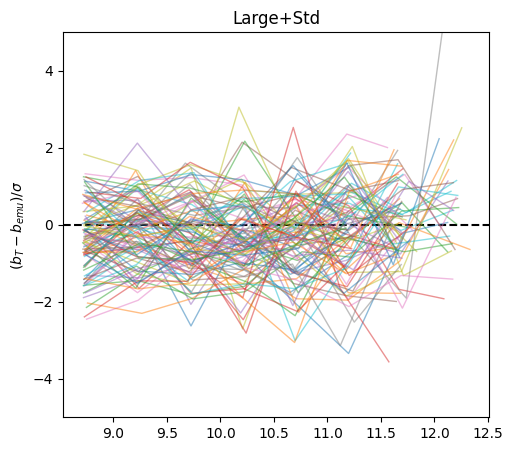

In [84]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

posteriors = [posterior_ensemble]
names = ["Large+Std", "Large+Bottleneck", "Large", "Small"]

plt.subplots_adjust(wspace=0, hspace=0)

ax.set_ylabel("$(b_{T}-b_{emu}) / \sigma$")
for j in range(1):
    ax.set_ylim(-5, 5)
    ax.axhline(0, color='k', ls='--')
    
    for i in range(len(test_ids)):
        mstar_test = mstar[test_ids[i]]
        bgal_test = bgal[test_ids[i]]
        
        id_sim = test_ids[i]
        theta_s = theta_full[ids_full == id_sim] # Parameters of the simulation selected for comparison
        logmstar_ = np.copy(theta_s[:, -1])
        
        theta_s = de_mean_theta(theta_s, mean_std_filename)
        x_s = x_full[ids_full == id_sim] # Biases of the sim selected for comparison

        samples = posteriors[j].sample(len(mstar_test), theta_s, show_progress_bars=False).cpu().numpy()
        samples = np.array(samples)
        samples = rescale_b1(samples, mean_std_filename)
        
        ms_test_w, b_test, bcov_test = mean_bias_relation(bgal_test, mstar_test, q=tr_q[test_ids[i]])
        ms_sample, b_sample, bcov_sample = mean_bias_relation(samples, logmstar_, q=None)
        
        ax.plot(ms_sample, (b_test[:,0] - b_sample[:,0]) / np.sqrt(bcov_test[:,0,0]), color='C'+str(i), lw=1, alpha=0.5)
        ax.set_title(names[j])

Text(0, 0.5, '$b_1$')

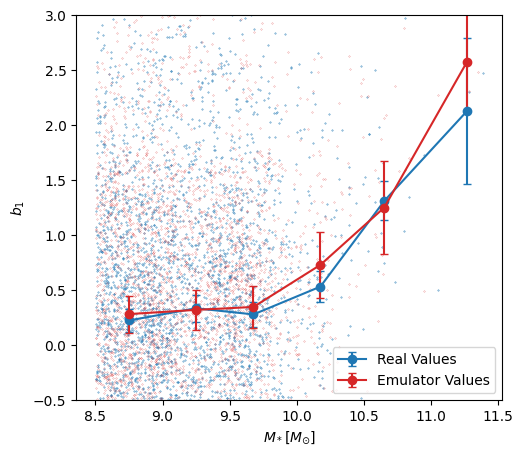

In [64]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

ax.errorbar(ms_test_w, b_test[:,0], yerr=np.sqrt(bcov_test[:,0,0]), marker='o', capsize=3, color="C0", label='Real Values')
ax.errorbar(ms_sample, b_sample[:,0], yerr=np.sqrt(bcov_sample[:,0,0]), marker='o', capsize=3, color="C3", label='Emulator Values')

ax.scatter(logmstar_, x_s, color='C0', s=0.1)
ax.scatter(logmstar_, samples[:,0], marker='.', s=0.1, color='C3')
ax.set_ylim(-0.5,3)

ax.legend()

ax.set_xlabel("$M_*[M_{\odot}]$")
ax.set_ylabel("$b_1$")

In [70]:
def get_pars_for_NPE(mstar, pars):
    theta = np.repeat(pars[:,np.newaxis], len(mstar), axis=1)
    theta = np.concatenate((theta, mstar[np.newaxis, :]), axis=0).T

    theta = de_mean_theta(theta, mean_std_filename)
    
    return theta

In [71]:
mstar_sample = mstar[test_ids[0]]

fid_pars = np.zeros(35)
for i in range(1,36):
    fid_pars[i-1] = data[0][i]

theta_fid = get_pars_for_NPE(mstar_sample, fid_pars)

In [72]:
fid_samples = np.array(posterior_ensemble.sample((len(mstar_sample),), theta_fid, show_progress_bars=False).cpu().numpy())
fid_ms, fid_b1, fid_b1cov = mean_bias_relation(fid_samples, mstar_sample, q=None)

In [73]:
i_par = 1

pars_var = {}
for i in range(5):
    pars_var[i] = np.copy(fid_pars)
    pars_var[i][i_par] = pars_var[i][i_par] + (i-2) * 0.2

In [81]:
samples_var = {}
ms_var = {}
b1_var = {}
b1cov_var = {}
for i in range(5):
    theta = get_pars_for_NPE(mstar_sample, pars_var[i])
    samples_var[i] = np.array(posterior_ensemble.sample((100*len(mstar_sample),), theta, show_progress_bars=False).cpu().numpy())
    ms_var[i], b1_var[i], b1cov_var[i] = mean_bias_relation(samples_var[i], mstar_sample, q=None)

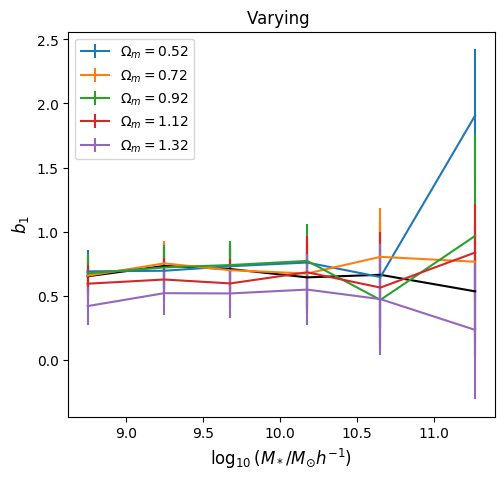

In [83]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.errorbar(fid_ms, 1+fid_b1[:,0], yerr=np.sqrt(fid_b1cov[:,0,0]), color='k')
for i in range(5):
    ax.errorbar(ms_var[i], 1+b1_var[i][:,0], yerr=np.sqrt(b1cov_var[i][:,0,0]), label="$\Omega_m=${:.2f}".format(pars_var[i][i_par]))

ax.set_xlabel("$\log_{10}(M_*/M_{\odot}h^{-1})$", fontsize=12)
ax.set_ylabel("$b_1$", fontsize=12)

ax.set_title("Varying ")

ax.legend(loc="upper left")

Text(0.5, 1.0, 'Large+Std')

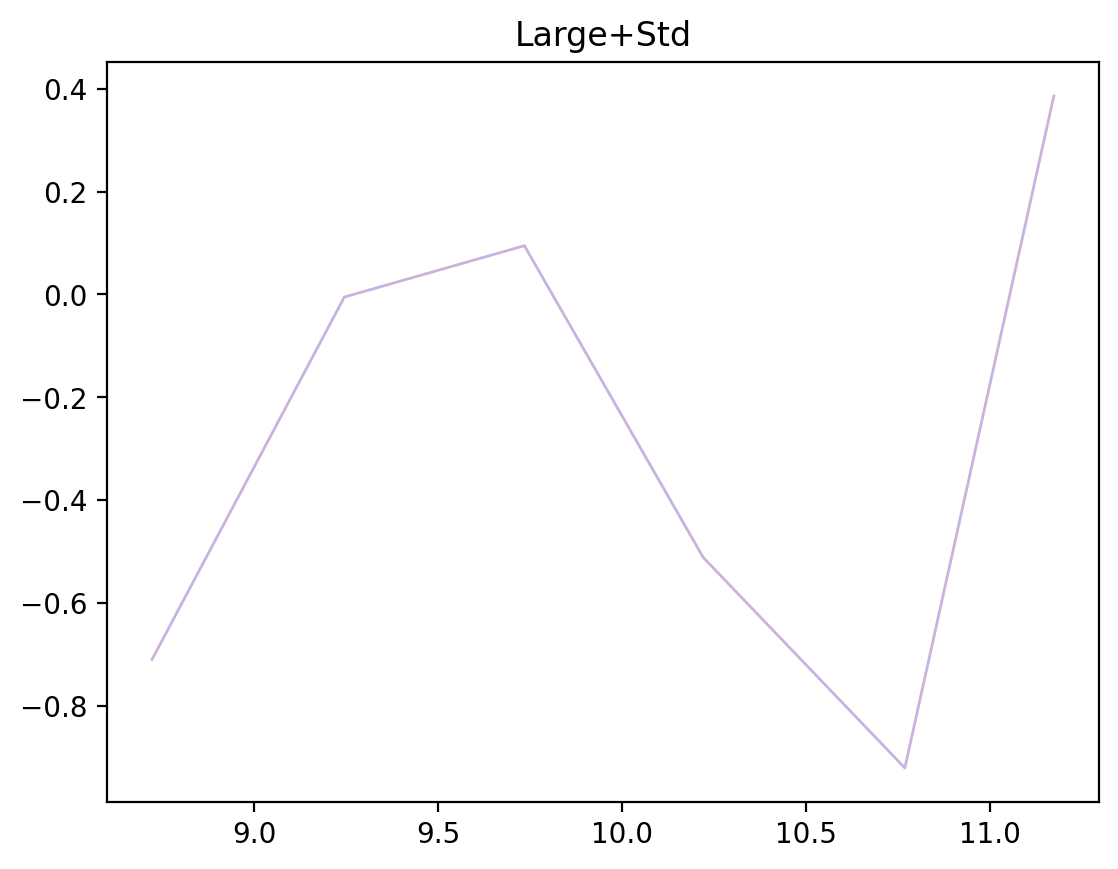

In [80]:
fig, ax = plt.subplots(dpi=200)

ms_w, b, bcov = mean_bias_relation(bgal_test, mstar_test, q=tr_q[test_ids[i]])

ax.plot(ms_sample, (b_test[:,0] - b_sample[:,0]) / np.sqrt(bcov_test[:,0,0]), color='C'+str(i), lw=1, alpha=0.5)
ax.set_title(names[j])